<a href="https://colab.research.google.com/github/mariadelmarhernandezh-ai/integracion2026/blob/main/Parcial1ID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Parcial 1**
Entidad prestadora de salud.

Una entidad prestadora de salud quiere mejorar la eficiencia en la prestación de sus servicios de salud, para lo cual quiere cerrar una de sus sucursales.

La entidad prestadora de salud quiere llevar a cabo el siguiente procedimiento, tomando como referencia una de las variables que caracterizan a los pacientes con Diabetes:

La entidad prestadora de salud quiere saber cual es la sucursal de atención que tiene una mayor afinidad con la sucursal que se quiere cerrar (Sabaneta).

Para determinar esta afinidad, la entidad prestadora de salud quiere llevar a cabo la estimación de la credibilidad entre la sucursal a cerrar y las demás sucursales utilizando la variable de referencia seleccionada.

Para reubicar a sus pacientes, la entidad prestadora de salud quiere clasificar sus pacientes en las otras sucursales mediante el método del valor de pertenencia.

Debido a que la entidad en salud tiene dudas frente al método de credibilidad y de integración por valor de pertenencia, la entidad prestadora de salud quiere hacer el mismo procedimiento de integración de pacientes mediante la utilización del método de aceptación y rechazo.

Es importante para antes y después de la integración de los datos, llevar a cabo el análisis de las medidas de tendencia central y dispersión para cada una de las bases de datos, para antes y después de la integración de los nuevos pacientes.


Carga de librerias de trabajo y base de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

nxl='/content/drive/MyDrive/Integracion de datos y prospectiva/3. Parcial - medical_attention_data.xlsx'
hojas= pd.read_excel(nxl, sheet_name=None)

Mounted at /content/drive


In [28]:
data = hojas["Sabaneta"].select_dtypes(include=["float64","int64"])

corr = data.corr()

np.fill_diagonal(corr.values, np.nan)

afinidad = corr.abs().mean().sort_values(ascending=False)

afinidad_df = afinidad.reset_index()
afinidad_df.columns = ["Variable","Coef promedio corr"]

display(afinidad_df)


,Variable,Coefpromediocorr
0,SkinThickness,0.059930
1,Age,0.039340
2,Diabetes,0.037752
3,BMI,0.037374
4,BloodPressure,0.035290
5,Glucose,0.032975
6,Insulin,0.029283
7,DiabetesPedigreeFunction,0.022588


Seleccione BMI como la variable de referencia porque es una variable continua que esta presente en todas las sucursales ya que glucosa no lo esta y estas tienen correlacion. Esto me permite realizar comparaciones estadísticas para hacer el proceso de credibilidad e integración de datos.

Eleccion de variable de referencia

In [27]:
variable="BMI"

In [29]:
# @title Caracterización de Distribuciones de Probabilidad
def caracterizacion(LDA, titulo="Distribución", xlabel="Variable"):

    # Configuración de la base
    LDA = np.array(LDA, dtype=float)
    LDA = LDA[~np.isnan(LDA)]

    # creación de la distribución
    plt.figure(figsize=(10,5))
    sns.histplot(LDA, bins=10, kde=True)
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.grid()
    plt.show()

    # caracterización de cada una de las variables
    np.set_printoptions(suppress=True)
    NI = 10    # número de clusters
    counts, bin_edges = np.histogram(LDA, bins=NI)

    print("El número de datos por intervalo es:")
    print(counts)
    print("Los intervalos inferiores:")
    print(bin_edges[:-1])
    print("Los intervalos superiores:")
    print(bin_edges[1:])

    XC = (bin_edges[:-1] + bin_edges[1:]) / 2

    # tabla de los datos
    Tabla = np.column_stack((bin_edges[:-1], bin_edges[1:], XC, counts))
    df = pd.DataFrame(Tabla, columns=['LI','LS','XC','ND'])

    display(df)

    # estimación de la media
    fr = counts / np.sum(counts)
    u = np.sum(XC * fr)
    sigma2 = np.sum(fr * (XC - u)**2)
    sigma = np.sqrt(sigma2)
    Cas = np.sum(fr * (XC - u)**3) / sigma**3
    Kur = (np.sum(fr * (XC - u)**4) / sigma**4) - 3

    print("Media estimada:", u)
    print("Desviación estándar estimada:", sigma)
    print("Coeficiente de asimetría:", Cas)
    print("Curtosis:", Kur)

    return u, sigma, Cas, Kur, df


Funcion de credibilidad

In [4]:
def credibilidad(LDAo, LDAe, nombre_externa="Sucursal externa"):

    # Caracterización de datos internos
    uo, sigmao, Caso, Kuro, dfo = caracterizacion(
        LDAo,
        titulo="Distribución datos internos",
        xlabel=variable
    )

    # Caracterización de datos externos
    ue, sigmae, Case, Kure, dfe = caracterizacion(
        LDAe,
        titulo=f"Distribución datos externos - {nombre_externa}",
        xlabel=variable
    )

    # valor esperado de la varianza
    NDo = len(LDAo)
    NDe = len(LDAe)
    EPV = (sigmao * NDo + sigmae * NDe) / (NDo + NDe)

    # Valor Hipotético de la Media
    uh = (uo * NDo + ue * NDe) / (NDo + NDe)
    VHM = ((NDo * uo**2 + NDe * ue**2) / (NDo + NDe)) - uh**2

    # estimación del fc
    if VHM == 0:
        fc = np.inf
        Cr = 0
    else:
        fc = EPV / VHM
        Cr = NDo / (NDo + fc)

    print("La media de los datos internos es:", uo)
    print("La media de los datos externos es:", ue)
    print("La credibilidad es:", Cr)

    return {
        "uo": uo,
        "sigmao": sigmao,
        "Caso": Caso,
        "Kuro": Kuro,
        "dfo": dfo,
        "ue": ue,
        "sigmae": sigmae,
        "Case": Case,
        "Kure": Kure,
        "dfe": dfe,
        "EPV": EPV,
        "VHM": VHM,
        "fc": fc,
        "Cr": Cr
    }

Hoja interna: Sabaneta

In [5]:
LDAo = hojas["Sabaneta"][variable].dropna().values

print("Número de datos internos (Sabaneta):", len(LDAo))

Número de datos internos (Sabaneta): 621


Comparacion de Sabaneta con todas las otras sucursales

COMPARANDO SABANETA VS Bello


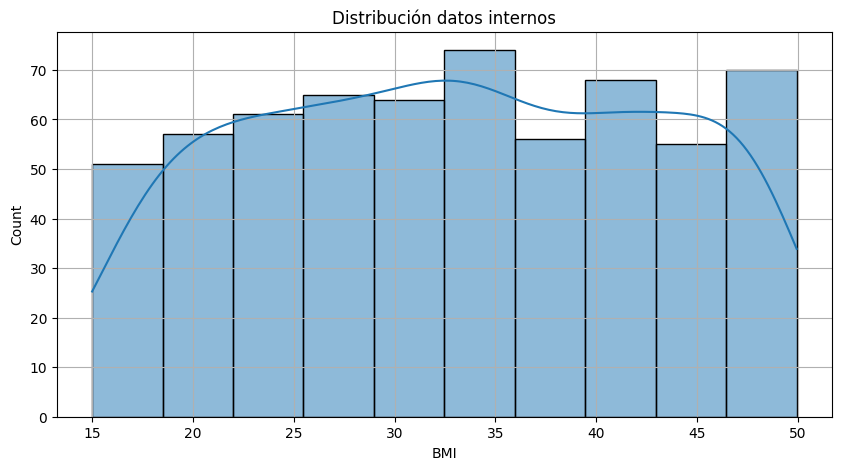

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,51.0
1,18.4971,21.9912,20.24415,57.0
2,21.9912,25.4853,23.73825,61.0
3,25.4853,28.9794,27.23235,65.0
4,28.9794,32.4735,30.72645,64.0
5,32.4735,35.9676,34.22055,74.0
6,35.9676,39.4617,37.71465,56.0
7,39.4617,42.9558,41.20875,68.0
8,42.9558,46.4499,44.70285,55.0
9,46.4499,49.9440,48.19695,70.0


Media estimada: 32.96582487922706
Desviación estándar estimada: 9.837867466860093
Coeficiente de asimetría: -0.025742157381107963
Curtosis: -1.1627829906265352


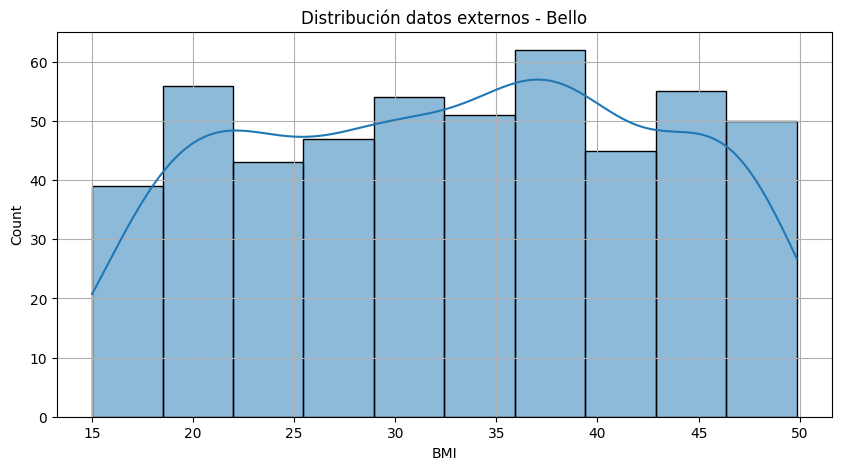

El número de datos por intervalo es:
[39 56 43 47 54 51 62 45 55 50]
Los intervalos inferiores:
[15.003 18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368]
Los intervalos superiores:
[18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368 49.853]


,LI,LS,XC,ND
0,15.003,18.488,16.7455,39.0
1,18.488,21.973,20.2305,56.0
2,21.973,25.458,23.7155,43.0
3,25.458,28.943,27.2005,47.0
4,28.943,32.428,30.6855,54.0
5,32.428,35.913,34.1705,51.0
6,35.913,39.398,37.6555,62.0
7,39.398,42.883,41.1405,45.0
8,42.883,46.368,44.6255,55.0
9,46.368,49.853,48.1105,50.0


Media estimada: 32.9278406374502
Desviación estándar estimada: 9.804369683459628
Coeficiente de asimetría: -0.0599453089846441
Curtosis: -1.1860520640673438
La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.9278406374502
La credibilidad es: 0.022050146729361828
COMPARANDO SABANETA VS Medellín


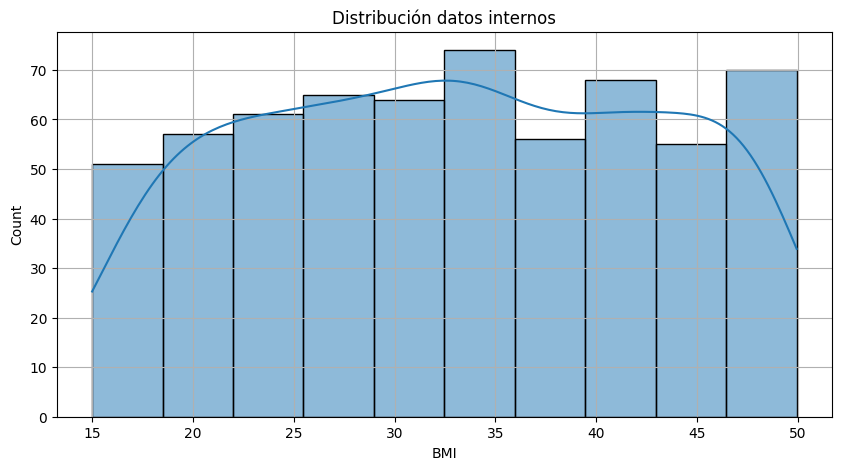

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,51.0
1,18.4971,21.9912,20.24415,57.0
2,21.9912,25.4853,23.73825,61.0
3,25.4853,28.9794,27.23235,65.0
4,28.9794,32.4735,30.72645,64.0
5,32.4735,35.9676,34.22055,74.0
6,35.9676,39.4617,37.71465,56.0
7,39.4617,42.9558,41.20875,68.0
8,42.9558,46.4499,44.70285,55.0
9,46.4499,49.9440,48.19695,70.0


Media estimada: 32.96582487922706
Desviación estándar estimada: 9.837867466860093
Coeficiente de asimetría: -0.025742157381107963
Curtosis: -1.1627829906265352


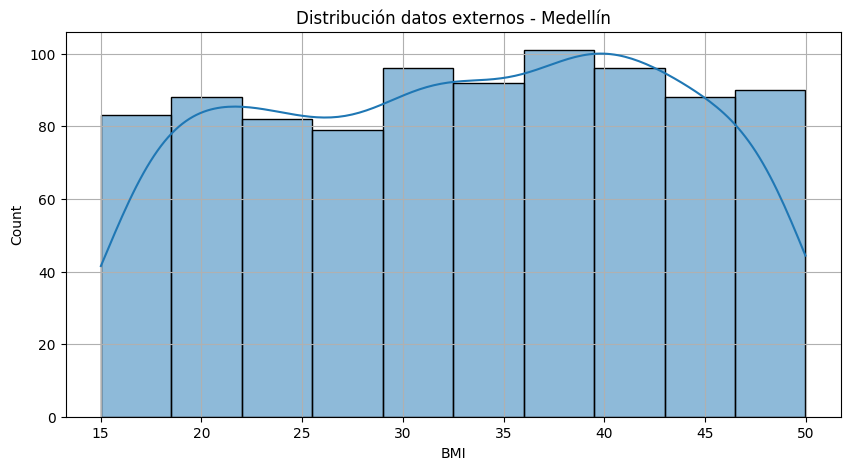

El número de datos por intervalo es:
[ 83  88  82  79  96  92 101  96  88  90]
Los intervalos inferiores:
[15.008  18.5043 22.0006 25.4969 28.9932 32.4895 35.9858 39.4821 42.9784
 46.4747]
Los intervalos superiores:
[18.5043 22.0006 25.4969 28.9932 32.4895 35.9858 39.4821 42.9784 46.4747
 49.971 ]


,LI,LS,XC,ND
0,15.0080,18.5043,16.75615,83.0
1,18.5043,22.0006,20.25245,88.0
2,22.0006,25.4969,23.74875,82.0
3,25.4969,28.9932,27.24505,79.0
4,28.9932,32.4895,30.74135,96.0
5,32.4895,35.9858,34.23765,92.0
6,35.9858,39.4821,37.73395,101.0
7,39.4821,42.9784,41.23025,96.0
8,42.9784,46.4747,44.72655,88.0
9,46.4747,49.9710,48.22285,90.0


Media estimada: 32.870381843575416
Desviación estándar estimada: 9.925651139843664
Coeficiente de asimetría: -0.06974264498227505
Curtosis: -1.1880147864485626
La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.870381843575416
La credibilidad es: 0.1215194250498064
COMPARANDO SABANETA VS Envigado


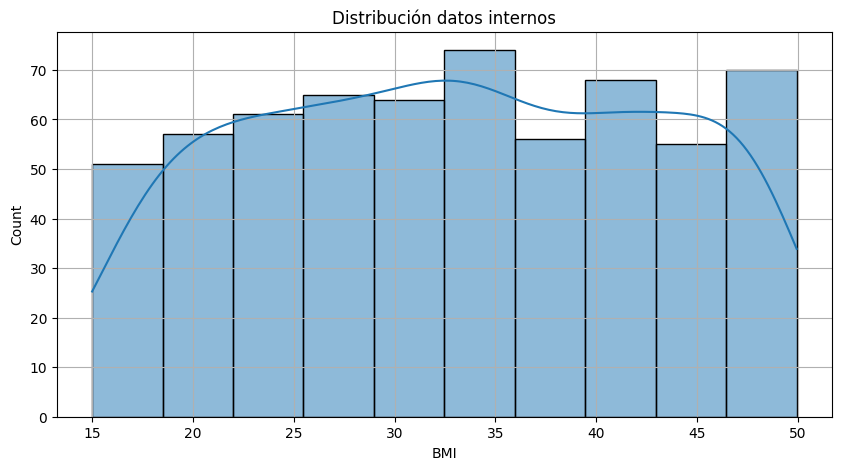

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,51.0
1,18.4971,21.9912,20.24415,57.0
2,21.9912,25.4853,23.73825,61.0
3,25.4853,28.9794,27.23235,65.0
4,28.9794,32.4735,30.72645,64.0
5,32.4735,35.9676,34.22055,74.0
6,35.9676,39.4617,37.71465,56.0
7,39.4617,42.9558,41.20875,68.0
8,42.9558,46.4499,44.70285,55.0
9,46.4499,49.9440,48.19695,70.0


Media estimada: 32.96582487922706
Desviación estándar estimada: 9.837867466860093
Coeficiente de asimetría: -0.025742157381107963
Curtosis: -1.1627829906265352


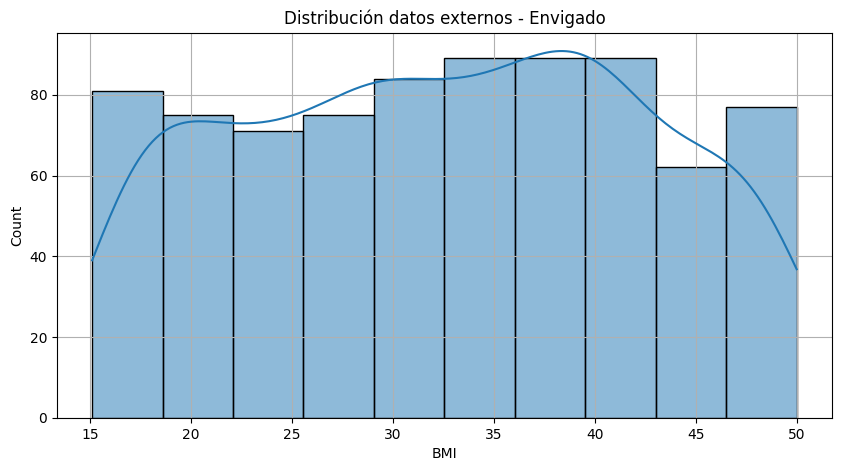

El número de datos por intervalo es:
[81 75 71 75 84 89 89 89 62 77]
Los intervalos inferiores:
[15.096  18.5857 22.0754 25.5651 29.0548 32.5445 36.0342 39.5239 43.0136
 46.5033]
Los intervalos superiores:
[18.5857 22.0754 25.5651 29.0548 32.5445 36.0342 39.5239 43.0136 46.5033
 49.993 ]


,LI,LS,XC,ND
0,15.0960,18.5857,16.84085,81.0
1,18.5857,22.0754,20.33055,75.0
2,22.0754,25.5651,23.82025,71.0
3,25.5651,29.0548,27.30995,75.0
4,29.0548,32.5445,30.79965,84.0
5,32.5445,36.0342,34.28935,89.0
6,36.0342,39.5239,37.77905,89.0
7,39.5239,43.0136,41.26875,89.0
8,43.0136,46.5033,44.75845,62.0
9,46.5033,49.9930,48.24815,77.0


Media estimada: 32.56653093434344
Desviación estándar estimada: 9.834442278208346
Coeficiente de asimetría: -0.040160184651065974
Curtosis: -1.1491841028973189
La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.56653093434344
La credibilidad es: 0.7126161490227079
COMPARANDO SABANETA VS Itagui


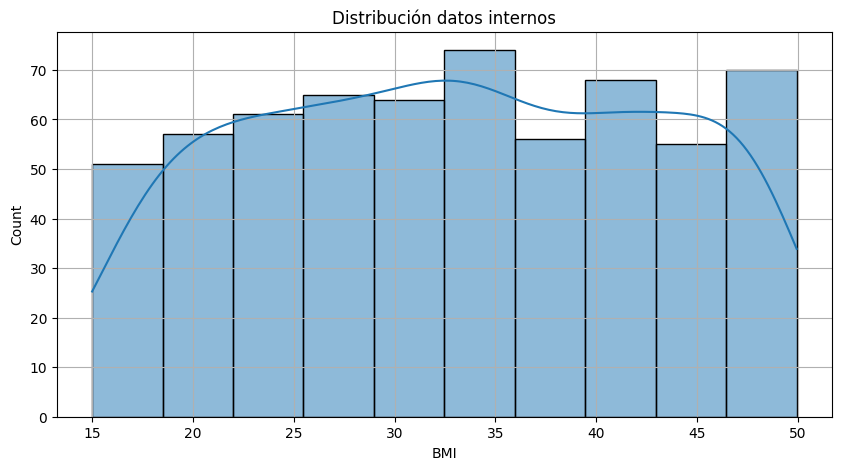

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,51.0
1,18.4971,21.9912,20.24415,57.0
2,21.9912,25.4853,23.73825,61.0
3,25.4853,28.9794,27.23235,65.0
4,28.9794,32.4735,30.72645,64.0
5,32.4735,35.9676,34.22055,74.0
6,35.9676,39.4617,37.71465,56.0
7,39.4617,42.9558,41.20875,68.0
8,42.9558,46.4499,44.70285,55.0
9,46.4499,49.9440,48.19695,70.0


Media estimada: 32.96582487922706
Desviación estándar estimada: 9.837867466860093
Coeficiente de asimetría: -0.025742157381107963
Curtosis: -1.1627829906265352


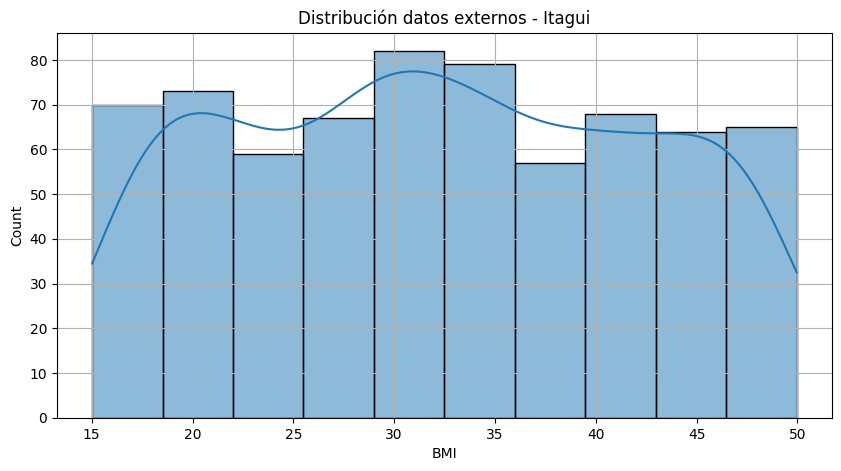

El número de datos por intervalo es:
[70 73 59 67 82 79 57 68 64 65]
Los intervalos inferiores:
[15.019  18.5136 22.0082 25.5028 28.9974 32.492  35.9866 39.4812 42.9758
 46.4704]
Los intervalos superiores:
[18.5136 22.0082 25.5028 28.9974 32.492  35.9866 39.4812 42.9758 46.4704
 49.965 ]


,LI,LS,XC,ND
0,15.0190,18.5136,16.7663,70.0
1,18.5136,22.0082,20.2609,73.0
2,22.0082,25.5028,23.7555,59.0
3,25.5028,28.9974,27.2501,67.0
4,28.9974,32.4920,30.7447,82.0
5,32.4920,35.9866,34.2393,79.0
6,35.9866,39.4812,37.7339,57.0
7,39.4812,42.9758,41.2285,68.0
8,42.9758,46.4704,44.7231,64.0
9,46.4704,49.9650,48.2177,65.0


Media estimada: 32.2467649122807
Desviación estándar estimada: 9.928945676671281
Coeficiente de asimetría: 0.027261582779057495
Curtosis: -1.172181742395808
La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.2467649122807
La credibilidad es: 0.8901234540257725
COMPARANDO SABANETA VS Caldas


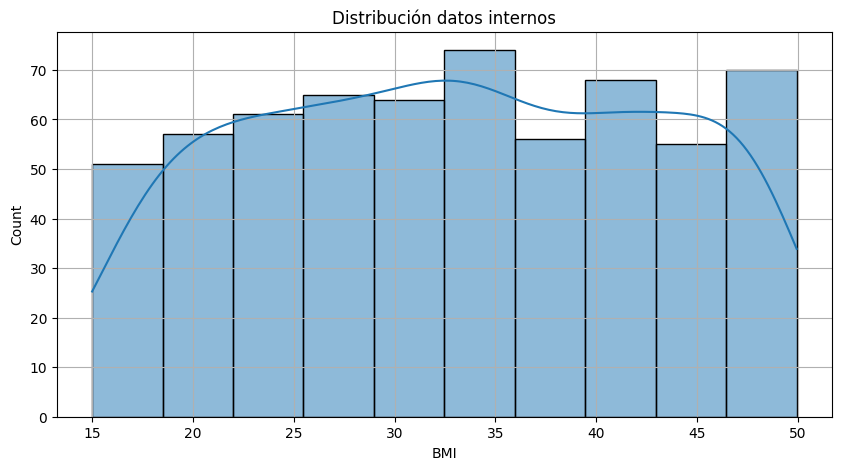

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,51.0
1,18.4971,21.9912,20.24415,57.0
2,21.9912,25.4853,23.73825,61.0
3,25.4853,28.9794,27.23235,65.0
4,28.9794,32.4735,30.72645,64.0
5,32.4735,35.9676,34.22055,74.0
6,35.9676,39.4617,37.71465,56.0
7,39.4617,42.9558,41.20875,68.0
8,42.9558,46.4499,44.70285,55.0
9,46.4499,49.9440,48.19695,70.0


Media estimada: 32.96582487922706
Desviación estándar estimada: 9.837867466860093
Coeficiente de asimetría: -0.025742157381107963
Curtosis: -1.1627829906265352


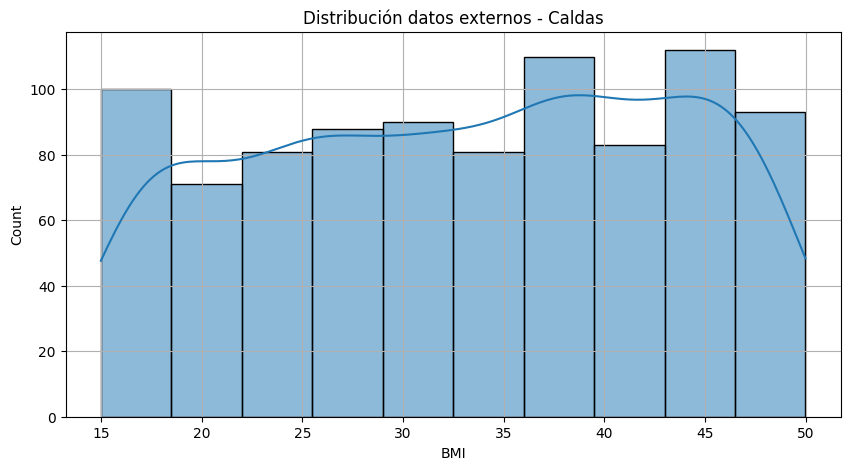

El número de datos por intervalo es:
[100  71  81  88  90  81 110  83 112  93]
Los intervalos inferiores:
[15.     18.4985 21.997  25.4955 28.994  32.4925 35.991  39.4895 42.988
 46.4865]
Los intervalos superiores:
[18.4985 21.997  25.4955 28.994  32.4925 35.991  39.4895 42.988  46.4865
 49.985 ]


,LI,LS,XC,ND
0,15.0000,18.4985,16.74925,100.0
1,18.4985,21.9970,20.24775,71.0
2,21.9970,25.4955,23.74625,81.0
3,25.4955,28.9940,27.24475,88.0
4,28.9940,32.4925,30.74325,90.0
5,32.4925,35.9910,34.24175,81.0
6,35.9910,39.4895,37.74025,110.0
7,39.4895,42.9880,41.23875,83.0
8,42.9880,46.4865,44.73725,112.0
9,46.4865,49.9850,48.23575,93.0


Media estimada: 33.05249092409241
Desviación estándar estimada: 10.142511067582673
Coeficiente de asimetría: -0.11052613512445673
Curtosis: -1.2181744314310725
La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 33.05249092409241
La credibilidad es: 0.10093355882909404
TABLA FINAL DE CREDIBILIDAD


,Sucursal,ND internos,ND externos,Media internos,Media externos,Sigma internos,Sigma externos,Credibilidad
3,Itagui,621,684,32.965825,32.246765,9.837867,9.928946,0.890123
2,Envigado,621,792,32.965825,32.566531,9.837867,9.834442,0.712616
1,Medellín,621,895,32.965825,32.870382,9.837867,9.925651,0.121519
4,Caldas,621,909,32.965825,33.052491,9.837867,10.142511,0.100934
0,Bello,621,502,32.965825,32.927841,9.837867,9.804370,0.022050


In [6]:
resultados_credibilidad = []

for sucursal in hojas.keys():
    if sucursal != "Sabaneta":
        print("COMPARANDO SABANETA VS", sucursal)

        LDAe = hojas[sucursal][variable].dropna().values
        resultado = credibilidad(LDAo, LDAe, nombre_externa=sucursal)

        resultados_credibilidad.append([
            sucursal,
            len(LDAo),
            len(LDAe),
            resultado["uo"],
            resultado["ue"],
            resultado["sigmao"],
            resultado["sigmae"],
            resultado["Cr"]
        ])

tabla_credibilidad = pd.DataFrame(
    resultados_credibilidad,
    columns=[
        "Sucursal",
        "ND internos",
        "ND externos",
        "Media internos",
        "Media externos",
        "Sigma internos",
        "Sigma externos",
        "Credibilidad"
    ]
)

print("TABLA FINAL DE CREDIBILIDAD")
display(tabla_credibilidad.sort_values(by="Credibilidad", ascending=False))

El análisis de credibilidad entre Sabaneta y las otras sucursales permitió observar la afinidad entre las bases de datos. Aca se observa que Bello presenta el menor valor de discrepancia (0.0220), esto muestra que su comportamiento es el más similar al de Sabaneta. Esto propone que estos datos de Bello son los más adecuados para hacer la integración de datos.

Seleccion de la sucursal con la mayor afinidad

La sucursal con mayor afinidad con Sabaneta es: Bello


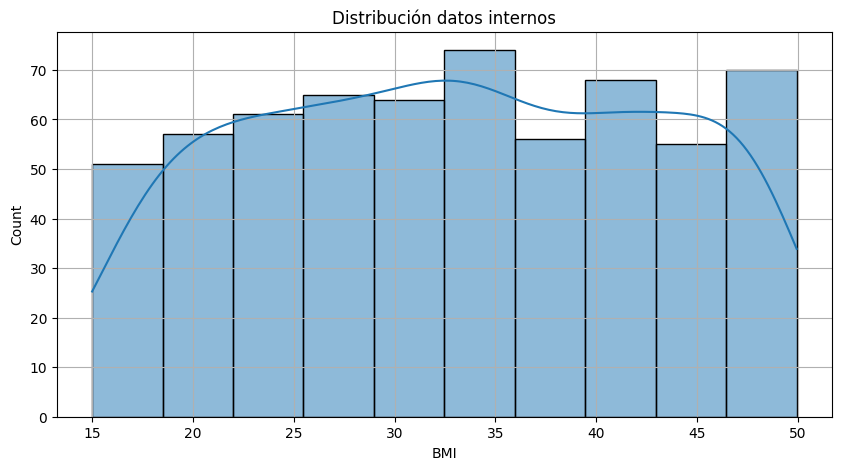

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,51.0
1,18.4971,21.9912,20.24415,57.0
2,21.9912,25.4853,23.73825,61.0
3,25.4853,28.9794,27.23235,65.0
4,28.9794,32.4735,30.72645,64.0
5,32.4735,35.9676,34.22055,74.0
6,35.9676,39.4617,37.71465,56.0
7,39.4617,42.9558,41.20875,68.0
8,42.9558,46.4499,44.70285,55.0
9,46.4499,49.9440,48.19695,70.0


Media estimada: 32.96582487922706
Desviación estándar estimada: 9.837867466860093
Coeficiente de asimetría: -0.025742157381107963
Curtosis: -1.1627829906265352


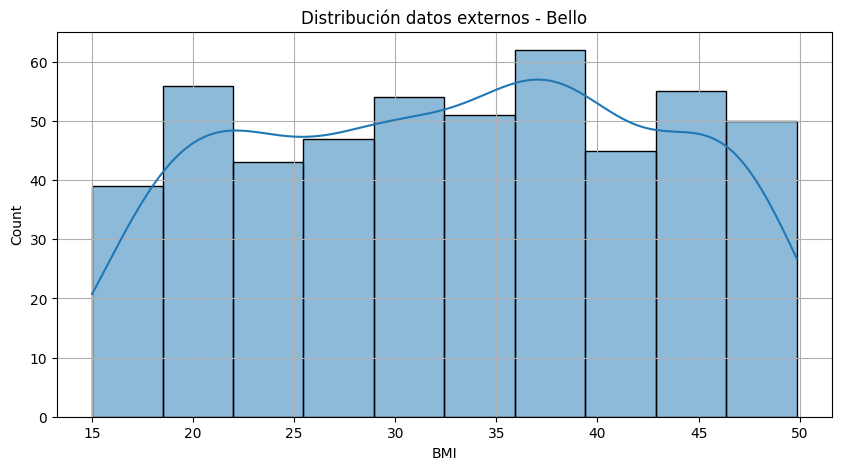

El número de datos por intervalo es:
[39 56 43 47 54 51 62 45 55 50]
Los intervalos inferiores:
[15.003 18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368]
Los intervalos superiores:
[18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368 49.853]


,LI,LS,XC,ND
0,15.003,18.488,16.7455,39.0
1,18.488,21.973,20.2305,56.0
2,21.973,25.458,23.7155,43.0
3,25.458,28.943,27.2005,47.0
4,28.943,32.428,30.6855,54.0
5,32.428,35.913,34.1705,51.0
6,35.913,39.398,37.6555,62.0
7,39.398,42.883,41.1405,45.0
8,42.883,46.368,44.6255,55.0
9,46.368,49.853,48.1105,50.0


Media estimada: 32.9278406374502
Desviación estándar estimada: 9.804369683459628
Coeficiente de asimetría: -0.0599453089846441
Curtosis: -1.1860520640673438
La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.9278406374502
La credibilidad es: 0.022050146729361828


In [30]:
mejorsucursal = tabla_credibilidad.sort_values(by="Credibilidad", ascending=True).iloc[0]["Sucursal"]
print("La sucursal con mayor afinidad con Sabaneta es:", mejorsucursal)

LDAe = hojas[mejorsucursal][variable].dropna().values

# Recalcular parámetros para la mejor sucursal
resultado_final = credibilidad(LDAo, LDAe, nombre_externa=mejorsucursal)

uo = resultado_final["uo"]
sigmao = resultado_final["sigmao"]
ue = resultado_final["ue"]
sigmae = resultado_final["sigmae"]

Integracion de datos por valor de pertenencia

MÉTODO 1 - Valor de pertenencia
Los datos integrados son: 140


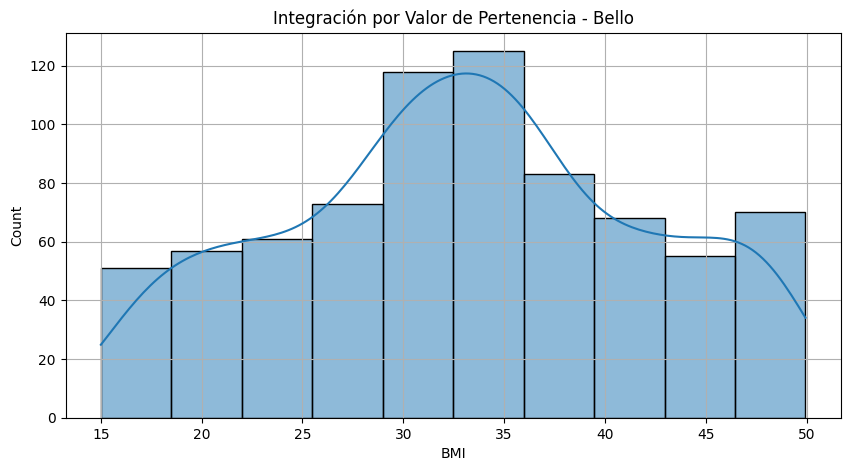

El número de datos por intervalo es:
[ 51  57  61  73 118 125  83  68  55  70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,51.0
1,18.4971,21.9912,20.24415,57.0
2,21.9912,25.4853,23.73825,61.0
3,25.4853,28.9794,27.23235,73.0
4,28.9794,32.4735,30.72645,118.0
5,32.4735,35.9676,34.22055,125.0
6,35.9676,39.4617,37.71465,83.0
7,39.4617,42.9558,41.20875,68.0
8,42.9558,46.4499,44.70285,55.0
9,46.4499,49.9440,48.19695,70.0


Media estimada: 32.99922201051248
Desviación estándar estimada: 8.976882829667213
Coeficiente de asimetría: -0.037215084349784794
Curtosis: -0.832136566121525
La media de los datos integrados es : 32.99922201051248
La media de los datos observados es:  32.96582487922706
La media de los datos externos es:  32.9278406374502
La discrepancia entre las medias es: 0.1013083440435028


In [31]:

print("MÉTODO 1 - Valor de pertenencia")

LDAint1 = np.copy(np.array(LDAo))   # Variable de integración
m1 = 0

for k in range(len(LDAe)):
    VP = np.exp(-0.5 * ((uo - LDAe[k]) / sigmao)**2)

    if VP > 0.9:
        m1 = m1 + 1
        LDAint1 = np.append(LDAint1, LDAe[k])

print("Los datos integrados son:", m1)

ui1, sigmai1, Casi1, Kuri1, dfi1 = caracterizacion(
    LDAint1,
    titulo=f"Integración por Valor de Pertenencia - {mejorsucursal}",
    xlabel=variable
)

print("La media de los datos integrados es :", ui1)
print("La media de los datos observados es: ", uo)
print("La media de los datos externos es: ", ue)

duoui1 = np.abs((uo - ui1) / uo) * 100
print("La discrepancia entre las medias es:", duoui1)


Integracion de datos por aceptacion y rechazo

MÉTODO 2 - Aceptacion/ Rechazo
Los datos integrados son: 355


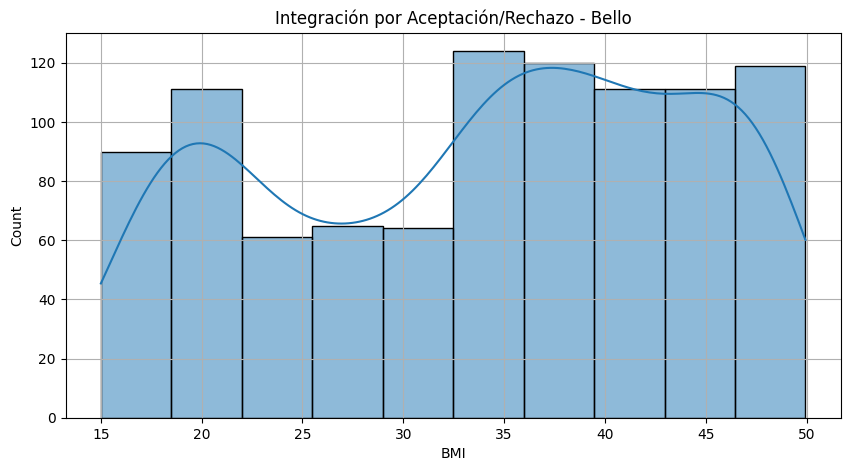

El número de datos por intervalo es:
[ 90 111  61  65  64 124 120 111 111 119]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,90.0
1,18.4971,21.9912,20.24415,111.0
2,21.9912,25.4853,23.73825,61.0
3,25.4853,28.9794,27.23235,65.0
4,28.9794,32.4735,30.72645,64.0
5,32.4735,35.9676,34.22055,124.0
6,35.9676,39.4617,37.71465,120.0
7,39.4617,42.9558,41.20875,111.0
8,42.9558,46.4499,44.70285,111.0
9,46.4499,49.9440,48.19695,119.0


Media estimada: 33.79094754098361
Desviación estándar estimada: 10.220827465730736
Coeficiente de asimetría: -0.24077360400423872
Curtosis: -1.2029855040139878
La media de los datos integrados es : 33.79094754098361
La media de los datos observados es:  32.96582487922706
La media de los datos externos es:  32.9278406374502
La discrepancia entre las medias es: 2.502963795929437


In [32]:

print("MÉTODO 2 - Aceptacion/ Rechazo")

LDAint2 = np.copy(np.array(LDAo))
m2 = 0

for k in range(len(LDAe)):
    VPo = np.exp(-0.5 * ((uo - LDAe[k]) / sigmao)**2)   # pertenencia a internos
    VPe = np.exp(-0.5 * ((ue - LDAe[k]) / sigmae)**2)   # pertenencia a externos

    if VPo > VPe:
        LDAint2 = np.append(LDAint2, LDAe[k])
        m2 = m2 + 1

print("Los datos integrados son:", m2)

ui2, sigmai2, Casi2, Kuri2, dfi2 = caracterizacion(
    LDAint2,
    titulo=f"Integración por Aceptación/Rechazo - {mejorsucursal}",
    xlabel=variable
)

print("La media de los datos integrados es :", ui2)
print("La media de los datos observados es: ", uo)
print("La media de los datos externos es: ", ue)

duoui2 = np.abs((uo - ui2) / uo) * 100
print("La discrepancia entre las medias es:", duoui2)


Aceptacion y rechazo II

MÉTODO 3 - Aceptacion/Rechazo 
Los datos integrados son: 502


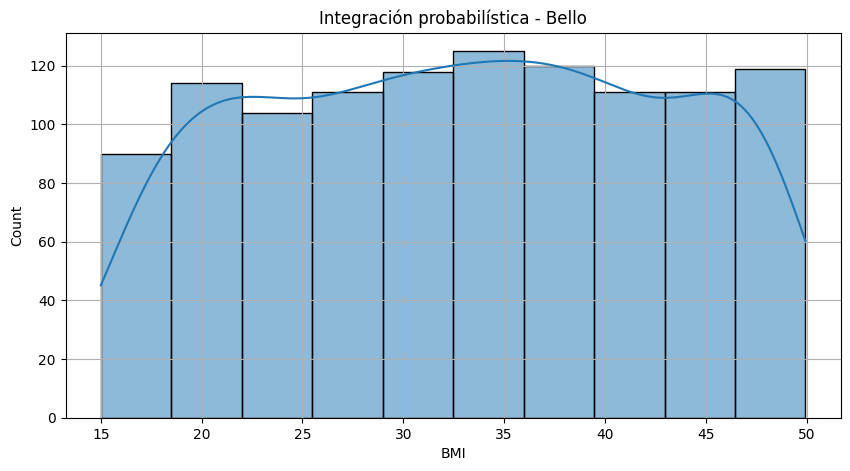

El número de datos por intervalo es:
[ 90 114 104 111 118 125 120 111 111 119]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,90.0
1,18.4971,21.9912,20.24415,114.0
2,21.9912,25.4853,23.73825,104.0
3,25.4853,28.9794,27.23235,111.0
4,28.9794,32.4735,30.72645,118.0
5,32.4735,35.9676,34.22055,125.0
6,35.9676,39.4617,37.71465,120.0
7,39.4617,42.9558,41.20875,111.0
8,42.9558,46.4499,44.70285,111.0
9,46.4499,49.9440,48.19695,119.0


Media estimada: 32.95421099732859
Desviación estándar estimada: 9.831795282883693
Coeficiente de asimetría: -0.04069361983408084
Curtosis: -1.1732789929531675
La media de los datos integrados es : 32.95421099732859
La media de los datos observados es:  32.96582487922706
La media de los datos externos es:  32.9278406374502
La discrepancia entre las medias es: 0.03523006610942649


In [33]:
print("MÉTODO 3 - Aceptacion/Rechazo ")

np.random.seed(123)

LDAint3 = np.copy(np.array(LDAo))
m3 = 0

for k in range(len(LDAe)):
    VPo = np.exp(-0.5 * ((uo - LDAe[k]) / sigmao)**2)
    VPe = np.exp(-0.5 * ((ue - LDAe[k]) / sigmae)**2)
    aleatorio = np.random.rand()

    if (VPo / VPe) > aleatorio:
        LDAint3 = np.append(LDAint3, LDAe[k])
        m3 = m3 + 1

print("Los datos integrados son:", m3)

ui3, sigmai3, Casi3, Kuri3, dfi3 = caracterizacion(
    LDAint3,
    titulo=f"Integración probabilística - {mejorsucursal}",
    xlabel=variable
)

print("La media de los datos integrados es :", ui3)
print("La media de los datos observados es: ", uo)
print("La media de los datos externos es: ", ue)

duoui3 = np.abs((uo - ui3) / uo) * 100
print("La discrepancia entre las medias es:", duoui3)

comparando los métodos de integración se puede observar que el método de aceptación/rechazo probabilístico fue el que permitió integrar mas observaciones (502 datos) de la base de datos externa (Bello). El método de valor de pertenencia fue el más restrictivo porque integro solamente 140 observaciones, mientras que el método de aceptación/rechazo permitió integrar 355 datos, es decir, es una alternativa intermedia.


Resumen de medidas

In [34]:
resumen = pd.DataFrame({

    "Base":[
        "Sabaneta original",
        "Integración VP",
        "Integración A/R"
    ],

    "n":[
        len(LDAo),
        len(LDAint1),
        len(LDAint2)
    ],

    "Media":[
        np.mean(LDAo),
        np.mean(LDAint1),
        np.mean(LDAint2)
    ],

    "Mediana":[
        np.median(LDAo),
        np.median(LDAint1),
        np.median(LDAint2)
    ],

    "Desv":[
        np.std(LDAo),
        np.std(LDAint1),
        np.std(LDAint2)
    ]

})

display(resumen)

,Base,n,Media,Mediana,Desv
0,Sabaneta original,621,32.992060,32.923,9.886847
1,Integración VP,761,33.007092,33.093,9.006240
2,Integración A/R,976,33.828724,35.321,10.273318
